In [40]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Імпортую данні

In [41]:
df_white = pd.read_csv('wine+quality/winequality-white.csv', sep=';')
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [42]:
df_red = pd.read_csv('wine+quality/winequality-red.csv', sep=';')
df_red.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Перевка на пусті значення:

In [43]:
df_white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [44]:
df_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Немає пустих значень. Можу переходити на перегляд фіч

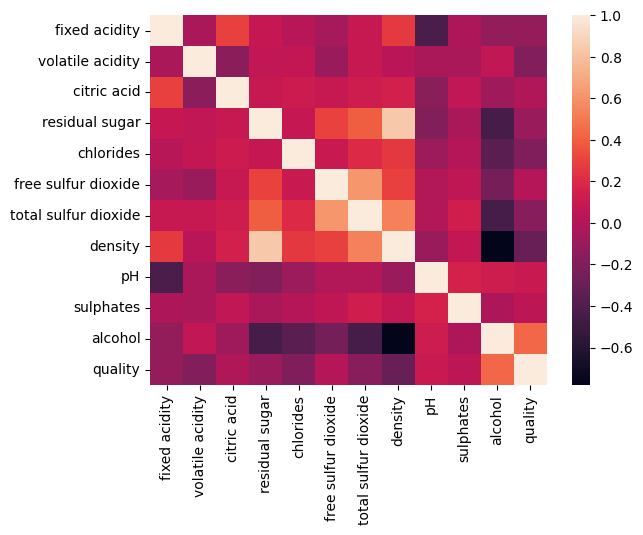

In [45]:
# корреляція між ознаками
corr_matrix = df_white.corr()
sns.heatmap(corr_matrix);

Гарна корреляція між density та residual sugar, тобто вони ростуть разом, велика від'ємна корреляція між alcohol та density і між pH та fixed acidity. Друге досить логічно, адже зі збільшенням лугів зменшується кислота. Також подивившись на корреляцію с таргетом, бачимо що найбільше з якістю росте і рівень алкоголю (і зменшується density), спробую створити нову вічу відношення alcohol та density

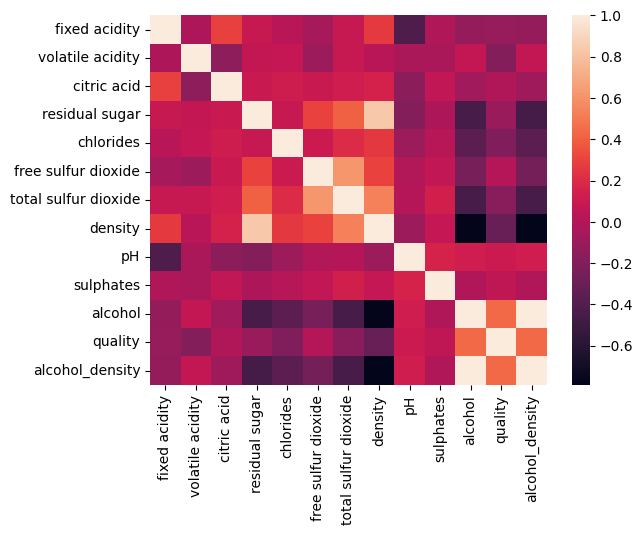

In [46]:
df_white['alcohol_density'] = df_white['alcohol'] / df_white['density']
corr_matrix = df_white.corr()
sns.heatmap(corr_matrix);

Кореляція з якістю непогана. Додам ще кислотність вцілом (fixed acidity + volatile acidity)

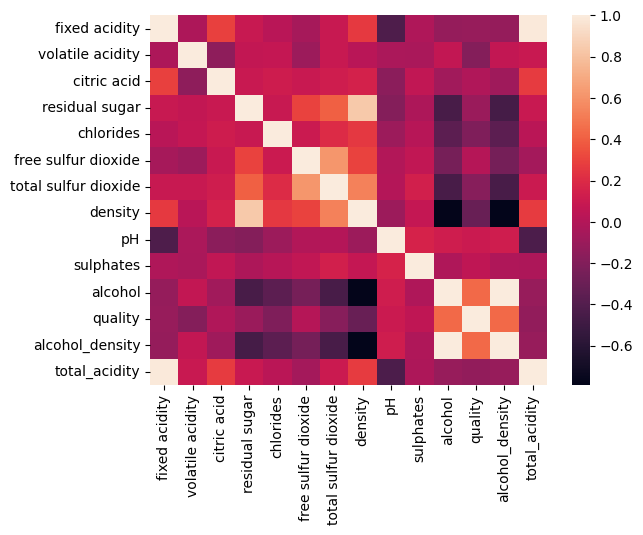

In [47]:
df_white['total_acidity'] = df_white['fixed acidity'] + df_white['volatile acidity']
corr_matrix = df_white.corr()
sns.heatmap(corr_matrix); 

Це мало чого дало, але нехай буде. Перейдемо до червоного вина

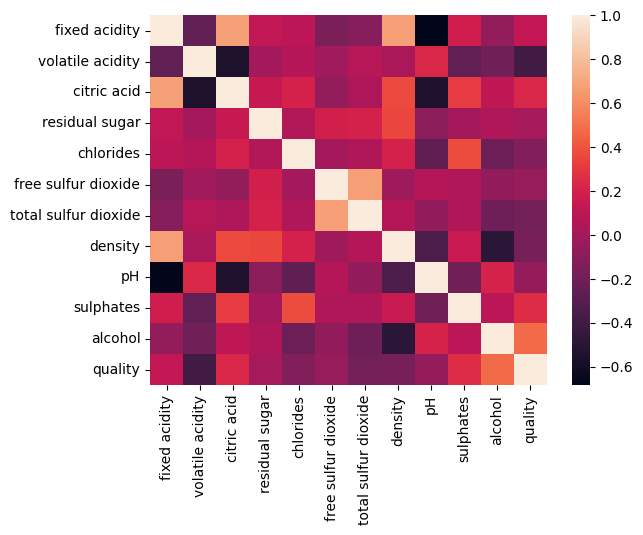

In [48]:
corr_matrix = df_red.corr()
sns.heatmap(corr_matrix);

Бачимо що між citric acid та fixed acidity і між total sulfur dioxide та free sulfur dioxide велика корреляція, тому можу зробити висновок, що в червоному вині серед фіксовоної кислоти пропорціальна кількість лимонної кислоти, та серед загальної кількості сульфур діоксіду велика частина вільного.  Зробля фічу відношення density до fixed acidity 

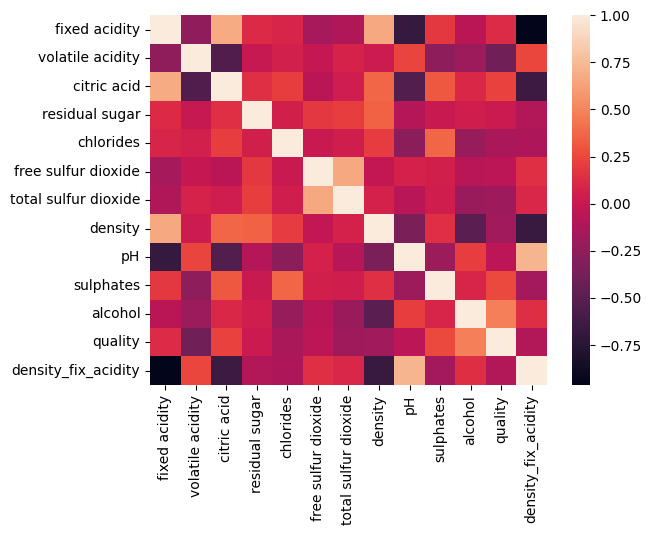

In [49]:
df_red['density_fix_acidity'] = df_red['density'] / df_red['fixed acidity']
corr_matrix = df_red.corr()
sns.heatmap(corr_matrix);

Тепер розіб'ю данні та масштабую 

In [50]:
# Відокремлюємо таргет
X = df_white.drop(columns=['quality'])
y = df_white['quality']

# Від окремемо тренувальні і тестувальні та валідаційні параметри
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Тепер розіб'ємо на валідаційні та тестувальні парараметри
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Масштабую
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Тепер будемо тренувати модель

In [51]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)
valid_score = model.score(X_val_scaled, y_val)
print(train_score)
print(test_score)
print(valid_score)

0.2850284104977817
0.27385802189039954
0.28066089029624175


Значення дуже близькі, тому модель стабільна. 

Спробую моделі Ridge та Lasso, щоб підберати оптимальні параметри

In [52]:
# Параметри для підбору
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Ridge регресія
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
print("Ridge - найкращий alpha:", ridge_cv.best_params_)
print("Ridge - R² на валідації:", ridge_cv.score(X_val_scaled, y_val))

# Lasso регресія
lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')
lasso_cv.fit(X_train_scaled, y_train)
print("\nLasso - найкращий alpha:", lasso_cv.best_params_)
print("Lasso - R² на валідації:", lasso_cv.score(X_val_scaled, y_val))

Ridge - найкращий alpha: {'alpha': 10}
Ridge - R² на валідації: 0.2775594438600337

Lasso - найкращий alpha: {'alpha': 0.001}
Lasso - R² на валідації: 0.27784413920105455


Порівняю результати всіх моделей на тестовій та валідаційній вибірці

In [53]:
# Збираємо результати на тестовій вибірці
models = {
    'LinearRegression': model,
    'Ridge': ridge_cv.best_estimator_,
    'Lasso': lasso_cv.best_estimator_
}

results = []
for name, m in models.items():
    y_pred = m.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Модель': name,
        'R²': round(r2, 4),
        'MSE': round(mse, 4),
        'MAE': round(mae, 4)
    })

# Виводимо таблицю результатів
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

          Модель     R²    MSE    MAE
LinearRegression 0.2739 0.5389 0.5744
           Ridge 0.2689 0.5426 0.5764
           Lasso 0.2695 0.5421 0.5762


Оцінка результатів

Всі моделі покузують схожий результат, але лінійна регресія трохи краща для цього набору данних. Значення для дисперсії 27% дуже маленька, помилка дуже велика, тому треба більш детально проаналізувати данні, обрати більш потрібні ознаки для корреляції та відкинути зайві. 

Я сто відсодків ще повернуся до цієї домашньої роботи, адже результат мені не дуже подобається, але зараз через сесію в університеті нема можливості більш детально понуритись у цю тему. Але я зрозумів, як працювати с scikit-learn, буду аналізувати вирсію hw5_Жосан, щоб вдосконалитись